##### Isolation forest

1. Įkeliame scaled_features.xlsx
2. Atskiriame account_number nuo požymių
3. Patikriname duomenis
4. Paruošiame X matricą modeliui
5. Sukuriame Isolation Forest modelį
6. Gauname anomalijų žymes
7. Gauname anomalijos balą
8. Išsaugome rezultatus
9. Padarome grafiką

In [13]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [14]:
scaled_features = pd.read_excel(r"Outputs/scaled_features.xlsx")


# original_features.head()
scaled_features.head()

,account_number,mean_call_duration,max_call_duration,unique_contacts_called,unique_destination_codes,unique_numbers_per_account,unique_active_days,days_between_first_and_last_call,active_day_ratio,avg_calls_per_active_day,avg_calls_per_own_number,night_calls_count,day_calls_count,max_calls_to_single_contact,mean_calls_to_single_contact,answered_calls_count,busy_calls_count,no_answer_calls_count,cancelled_calls_count,webrtc_calls_count
0,0000df940049fa1bbefc699a17671295,0.189056,0.418073,1.588235,2.125,0,0.655172,-0.129611,0.463529,0.130939,0.755952,0.000000,0.723032,1.106667,-0.097895,0.939850,0.000,0.000000,0.157895,0
1,000a38dacb7099ae710216b9cd54087c,2.795097,1.116928,-0.117647,0.000,0,0.494253,0.237288,0.014483,-0.599371,0.250000,0.000000,0.227405,0.533333,0.704444,0.315789,0.250,-0.181818,-0.052632,0
2,000b1bddfe23f65af9990f52b3ae004e,-0.201718,-0.491371,-0.411765,-0.375,2,-0.459770,-0.911266,-0.157743,1.152263,-0.458333,0.000000,-0.443149,-0.400000,-0.490000,-0.406015,-0.250,-0.181818,-0.421053,0
3,000d7412614cfc8e6d918ca63e1f37dc,0.623868,0.175296,-0.294118,-0.250,0,-0.436782,-0.556331,-0.546958,2.263374,-0.375000,0.000000,-0.384840,-0.360000,-0.373333,-0.345865,0.000,-0.181818,-0.368421,0
4,0013a4303bdffc2658cd40f80227a524,-0.207689,0.331976,1.705882,1.000,0,3.563218,0.436690,1.680298,1.104915,5.726190,44.666667,4.810496,9.413333,1.962500,4.932331,12.375,2.545455,9.631579,0


In [15]:
# Atskiriame vartotojo ID
# Išsaugome account_number atskirai
account_numbers = scaled_features["account_number"]

# Modeliui paliekame tik požymius, be account_number
X = scaled_features.drop(columns=["account_number"])

print("Modeliui naudojamų duomenų dydis:", X.shape)
print("Naudojami požymiai:")
print(X.columns.tolist())
print("Ar skaitinai įrašai:")
print(X.dtypes.apply(lambda x: x == 'int64' or x == 'float64').tolist())

Modeliui naudojamų duomenų dydis: (9603, 19)
Naudojami požymiai:
['mean_call_duration', 'max_call_duration', 'unique_contacts_called', 'unique_destination_codes', 'unique_numbers_per_account', 'unique_active_days', 'days_between_first_and_last_call', 'active_day_ratio', 'avg_calls_per_active_day', 'avg_calls_per_own_number', 'night_calls_count', 'day_calls_count', 'max_calls_to_single_contact', 'mean_calls_to_single_contact', 'answered_calls_count', 'busy_calls_count', 'no_answer_calls_count', 'cancelled_calls_count', 'webrtc_calls_count']
Ar skaitinai įrašai:
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


n_estimators = 200 - reiškia, kad modelis sukurs 200 izoliacijos medžių. 

contamination = 0.02 - reiškia, kad modelis tikėsis apie 2 % anomalinių vartotojų. (reiketu tureti bent +- ideja kiek anomaliju galetu buti)

max_samples = "auto" - leidžia modeliui automatiškai pasirinkti imties dydį medžių kūrimui.

random_state = 42 - užtikrina, kad kiekvieną kartą paleidus kodą rezultatai būtų tokie patys.

fit(X) - modelis išmoksta bendrą vartotojų elgsenos struktūrą.

predict(X) - kiekvienam vartotojui priskiria žymę:  1  = normalus vartotojas ; -1  = anomalinis / įtartinas vartotojas

score_samples(X) - 



In [16]:
# Isolation Forest modelio kūrimas ir apmokymas
iForest = IsolationForest(n_estimators=200, contamination=0.01, max_samples="auto", random_state=42)
iForest.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [17]:
# Gauname prognozes ir anomalijų balus
predictions = iForest.predict(X)
raw_scores = iForest.score_samples(X)

# Apverčiame score, kad didesnė reikšmė reikštų didesnį įtartinumą
anomaly_scores = -raw_scores


In [18]:
# Rezultatų lentelė
results = pd.DataFrame({
    "account_number": account_numbers,
    "iforest_prediction": predictions,
    "iforest_anomaly_score": anomaly_scores
})

results["iforest_is_anomaly"] = results["iforest_prediction"].map({
    1: 0,
    -1: 1
})

results

,account_number,iforest_prediction,iforest_anomaly_score,iforest_is_anomaly
0,0000df940049fa1bbefc699a17671295,1,0.378449,0
1,000a38dacb7099ae710216b9cd54087c,1,0.385310,0
2,000b1bddfe23f65af9990f52b3ae004e,1,0.391056,0
3,000d7412614cfc8e6d918ca63e1f37dc,1,0.368099,0
4,0013a4303bdffc2658cd40f80227a524,1,0.637199,0
...,...,...,...,...
9598,fff3d1a7b92ca72dbca37b0ba062af95,1,0.386761,0
9599,fff65074634a70efc96bc738e7bf368c,1,0.347344,0
9600,fff8217ecefc2d900e361d22d6e90ce0,1,0.550627,0
9601,fff86cfbdc7d0f8b59b65db318798076,1,0.370960,0


In [19]:
results.to_excel(r"Outputs/iforest_results.xlsx", index=False)

In [20]:
# Patikriname, kiek vartotojų pažymėta anomalijomis

anomaly_count = results["iforest_is_anomaly"].sum()
total_count = len(results)
anomaly_percent = anomaly_count / total_count * 100

print("Bendras vartotojų skaičius:", total_count)
print("Isolation Forest pažymėtų įtartinų vartotojų skaičius:", anomaly_count)
print(f"Įtartinų vartotojų dalis: {anomaly_percent:.2f}%")

Bendras vartotojų skaičius: 9603
Isolation Forest pažymėtų įtartinų vartotojų skaičius: 97
Įtartinų vartotojų dalis: 1.01%


In [21]:
#Išsivedame įtartinus vartotojus
anomalies = results[results["iforest_is_anomaly"] == 1]

# Jų anomalijos balai
scores = anomalies["iforest_anomaly_score"]

# Min, max, vidurkis
min_score = scores.min()
max_score = scores.max()
mean_score = scores.mean()

print("\n--- Anomalijų balų statistika ---")
print(f"Mažiausias anomalijos balas: {min_score:.3f}")
print(f"Didžiausias anomalijos balas: {max_score:.3f}")
print(f"Vidutinis anomalijos balas: {mean_score:.3f}")

# Intervalai
interval_065_070 = ((scores >= 0.65) & (scores < 0.70)).sum()
interval_070_075 = ((scores >= 0.70) & (scores < 0.75)).sum()
above_075 = (scores >= 0.75).sum()

total_anomalies = len(scores)

print("\n--- Pasiskirstymas pagal intervalus ---")
print(f"[0.65–0.70): {interval_065_070} vartotojai ({interval_065_070 / total_anomalies * 100:.1f}%)")
print(f"[0.70–0.75): {interval_070_075} vartotojai ({interval_070_075 / total_anomalies * 100:.1f}%)")
print(f">= 0.75: {above_075} vartotojai ({above_075 / total_anomalies * 100:.1f}%)")

anomalies



--- Anomalijų balų statistika ---
Mažiausias anomalijos balas: 0.660
Didžiausias anomalijos balas: 0.779
Vidutinis anomalijos balas: 0.710

--- Pasiskirstymas pagal intervalus ---
[0.65–0.70): 44 vartotojai (45.4%)
[0.70–0.75): 35 vartotojai (36.1%)
>= 0.75: 18 vartotojai (18.6%)


,account_number,iforest_prediction,iforest_anomaly_score,iforest_is_anomaly
102,02fd177ff43e28b012e98c1e7fe5a002,-1,0.746592,1
213,06090a2f32120d254b6bb95d53f10786,-1,0.665397,1
255,0760c6e3d4f363f6816633283ae537f1,-1,0.674020,1
261,07781e8d394369feab90c88842f472d3,-1,0.760307,1
420,0b961f3236e57b42c3c5f6a2893d1b01,-1,0.700471,1
...,...,...,...,...
9179,f5200c4b7a90b38090e2cec03a4568a2,-1,0.699628,1
9210,f5e7a215add1430e9bb32b7a96df405f,-1,0.702690,1
9266,f74803df15deafa94643360a4a00bd22,-1,0.752183,1
9323,f87dc865abdfe6d1ea55e722782dab60,-1,0.677116,1


In [22]:
anomalies.to_excel(r"Outputs/iforest_anomalies.xlsx", index=False)

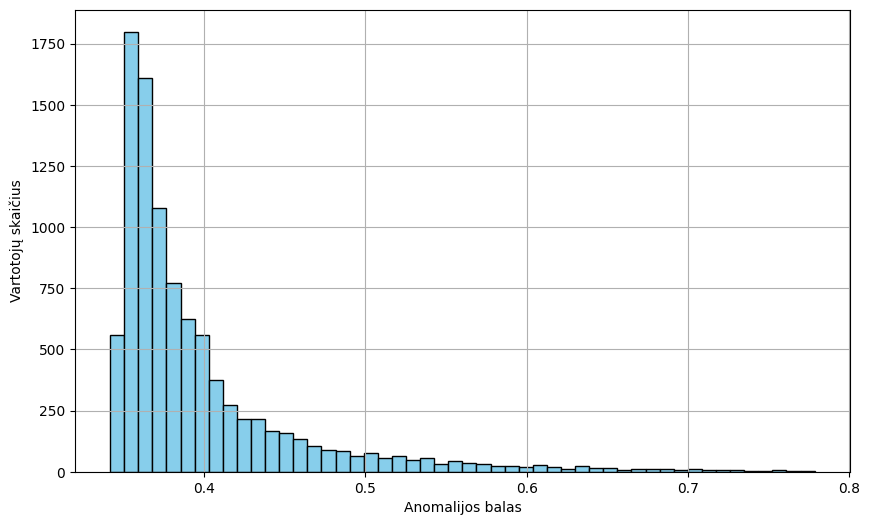

In [23]:
# Anomalijos balų grafikas

plt.figure(figsize=(10, 6))
plt.hist(results["iforest_anomaly_score"], bins=50, color='skyblue', edgecolor='black')
# plt.title("Isolation Forest anomalijos balų pasiskirstymas")
plt.xlabel("Anomalijos balas")
plt.ylabel("Vartotojų skaičius")
plt.grid(True)

plt.show()